In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | Device: {device}')

PyTorch: 2.9.0+cu126 | Device: cuda


## 1. Phân tích Dữ liệu

100%|██████████| 170M/170M [00:10<00:00, 15.9MB/s]


Các lớp: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 50000 | Test: 10000


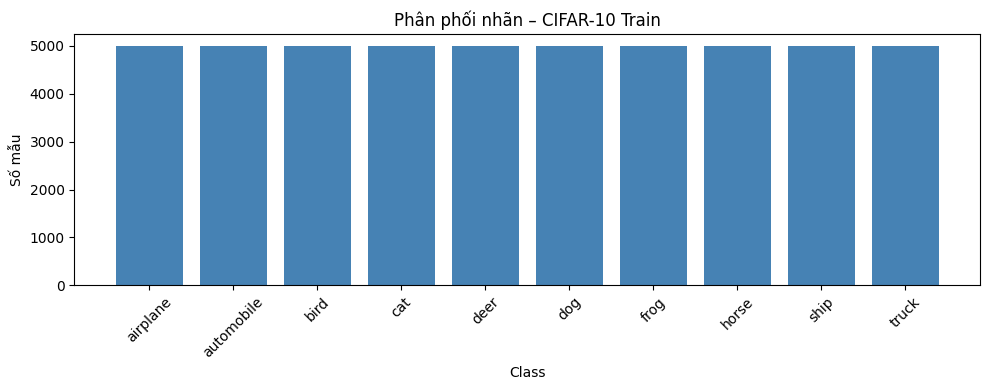

→ Dataset cân bằng hoàn toàn: 5000 mẫu/lớp


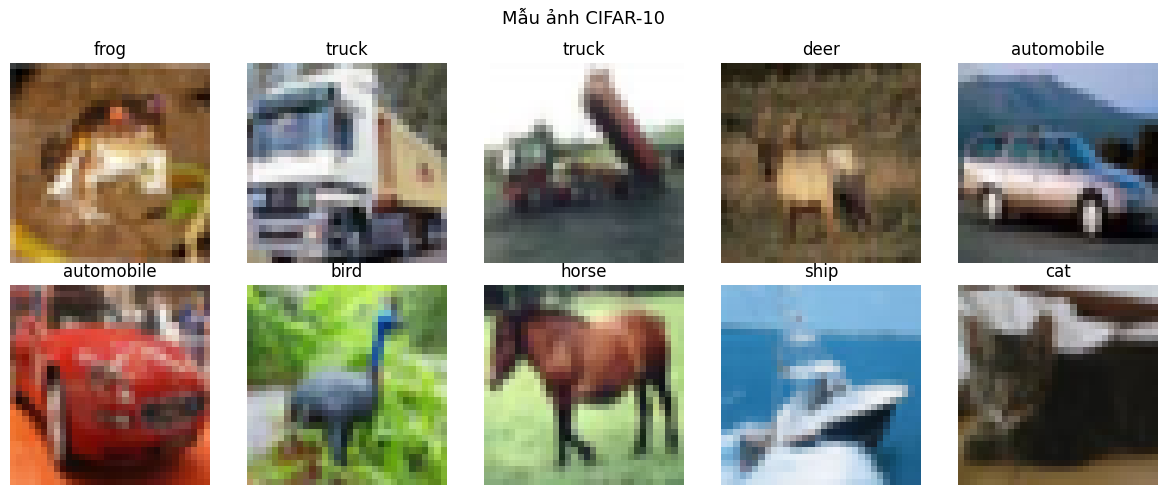

In [2]:
raw_transform = transforms.ToTensor()
raw_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=raw_transform)
raw_test  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=raw_transform)

classes = raw_train.classes
print('Các lớp:', classes)
print(f'Train: {len(raw_train)} | Test: {len(raw_test)}')

# Phân phối nhãn
train_counts = Counter(raw_train.targets)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([classes[k] for k in sorted(train_counts)],
       [train_counts[k] for k in sorted(train_counts)], color='steelblue')
ax.set_title('Phân phối nhãn – CIFAR-10 Train')
ax.set_xlabel('Class'); ax.set_ylabel('Số mẫu')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print('→ Dataset cân bằng hoàn toàn: 5000 mẫu/lớp')

# Hiển thị mẫu
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flatten()):
    img, label = raw_train[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(classes[label]); ax.axis('off')
plt.suptitle('Mẫu ảnh CIFAR-10', fontsize=13)
plt.tight_layout(); plt.show()

## 2. Data Augmentation (bao gồm Cutout)

Train batches: 391 | Test batches: 40


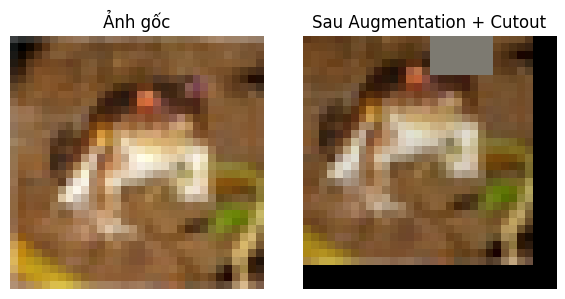

In [3]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Cutout: che một ô vuông ngẫu nhiên trên ảnh để buộc model học nhiều vùng hơn
class Cutout:
    def __init__(self, n_holes=1, length=8):
        self.n_holes = n_holes
        self.length  = length

    def __call__(self, img):          # img: [C, H, W] tensor
        h, w = img.shape[1], img.shape[2]
        mask = torch.ones(h, w, dtype=torch.float32)
        for _ in range(self.n_holes):
            y = np.random.randint(h)
            x = np.random.randint(w)
            y1, y2 = max(0, y - self.length // 2), min(h, y + self.length // 2)
            x1, x2 = max(0, x - self.length // 2), min(w, x + self.length // 2)
            mask[y1:y2, x1:x2] = 0.0
        return img * mask.unsqueeze(0)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    Cutout(n_holes=1, length=8),       # Cutout sau normalize
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=False, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

# Minh hoạ Cutout
sample_img, _ = train_dataset[0]
mean_t = torch.tensor(CIFAR_MEAN).view(3,1,1)
std_t  = torch.tensor(CIFAR_STD).view(3,1,1)
img_show = (sample_img * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(raw_train[0][0].permute(1,2,0).numpy()); axes[0].set_title('Ảnh gốc'); axes[0].axis('off')
axes[1].imshow(img_show); axes[1].set_title('Sau Augmentation + Cutout'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 3. Xây dựng Mô hình CNN (Sâu hơn)

In [4]:
class CIFAR10_CNN(nn.Module):
    """
    CNN 4 khối – mỗi khối: Conv(3×3)→BN→ReLU→Conv(3×3)→BN→ReLU→MaxPool→Dropout
    Tăng channel: 3→64→128→256→512, dùng GAP thay Flatten để giảm params.
    Target: >90% CIFAR-10 test accuracy.
    """
    def __init__(self, num_classes=10, dropout=0.35):
        super().__init__()

        def block(in_c, out_c, drop=dropout):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(drop),
            )

        self.features = nn.Sequential(
            block(3,   64,  drop=0.10),   # 32→16
            block(64,  128, drop=0.20),   # 16→8
            block(128, 256, drop=0.30),   # 8→4
            block(256, 512, drop=0.35),   # 4→2
        )

        self.gap = nn.AdaptiveAvgPool2d(1)  # 2×2 → 1×1  [B,512,1,1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


model = CIFAR10_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng params: {n_params:,}')

# Kiểm tra forward pass
with torch.no_grad():
    out = model(torch.zeros(2, 3, 32, 32).to(device))
print(f'Output shape: {out.shape}  ✓')

Tổng params: 4,821,194
Output shape: torch.Size([2, 10])  ✓


## 4. Huấn luyện với Warmup + Cosine LR

In [5]:
NUM_EPOCHS  = 60
WARMUP_EPOCHS = 5

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)

# Warmup: lr tăng tuyến tính từ 0 → max_lr trong WARMUP_EPOCHS đầu
# sau đó Cosine Annealing giảm về eta_min
def warmup_cosine(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS          # tuyến tính 0→1
    progress = (epoch - WARMUP_EPOCHS) / (NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))    # cosine 1→0

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

train_losses, train_accs = [], []
test_losses,  test_accs  = [], []
best_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    r_loss = correct = total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        r_loss  += loss.item()
        _, pred  = out.max(1)
        correct += pred.eq(labels).sum().item()
        total   += labels.size(0)
    scheduler.step()

    t_loss = r_loss / len(train_loader)
    t_acc  = 100 * correct / total
    train_losses.append(t_loss); train_accs.append(t_acc)

    # ── Evaluate ──
    model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out    = model(imgs)
            v_loss += criterion(out, labels).item()
            _, pred = out.max(1)
            v_correct += pred.eq(labels).sum().item()
            v_total   += labels.size(0)

    v_loss /= len(test_loader)
    v_acc   = 100 * v_correct / v_total
    test_losses.append(v_loss); test_accs.append(v_acc)

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), 'best_cifar10.pth')

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
              f'Train {t_loss:.4f}/{t_acc:.2f}% | '
              f'Test {v_loss:.4f}/{v_acc:.2f}% | '
              f'LR {lr_now:.6f}')

print(f'\n✅ Best Test Accuracy: {best_acc:.2f}%')

Epoch   1/60 | Train 2.0710/27.23% | Test 1.6646/44.59% | LR 0.000400
Epoch   5/60 | Train 1.3491/63.19% | Test 1.1514/70.32% | LR 0.001000
Epoch  10/60 | Train 1.0803/76.17% | Test 0.9539/81.58% | LR 0.000980
Epoch  15/60 | Train 0.9605/81.68% | Test 0.8290/86.61% | LR 0.000921
Epoch  20/60 | Train 0.8875/84.69% | Test 0.7998/87.56% | LR 0.000827
Epoch  25/60 | Train 0.8355/86.85% | Test 0.7601/88.94% | LR 0.000708
Epoch  30/60 | Train 0.7933/88.72% | Test 0.7453/89.56% | LR 0.000571
Epoch  35/60 | Train 0.7637/89.84% | Test 0.7106/91.02% | LR 0.000429
Epoch  40/60 | Train 0.7335/91.06% | Test 0.7078/91.12% | LR 0.000292
Epoch  45/60 | Train 0.7112/91.98% | Test 0.6950/91.86% | LR 0.000173
Epoch  50/60 | Train 0.6977/92.60% | Test 0.6930/92.06% | LR 0.000079
Epoch  55/60 | Train 0.6911/92.87% | Test 0.6899/92.08% | LR 0.000020
Epoch  60/60 | Train 0.6892/92.94% | Test 0.6885/92.18% | LR 0.000000

✅ Best Test Accuracy: 92.25%


## 5. Trực quan & Đánh giá

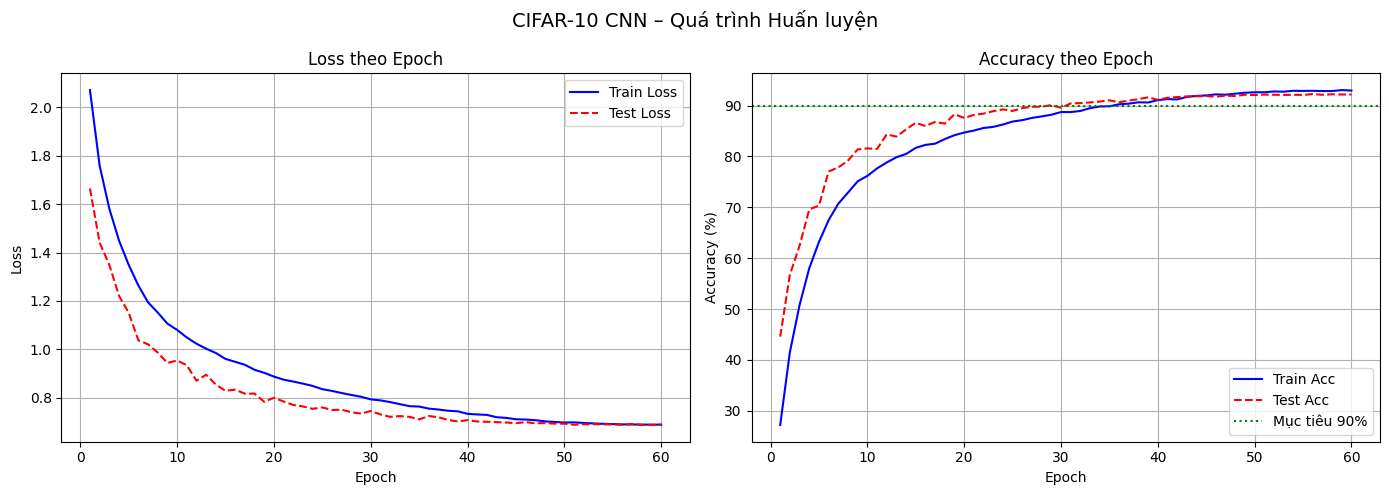

Train Acc cuối: 92.94%
Test  Acc cuối: 92.18%
Best  Test Acc: 92.25%
Generalization gap: 0.76% (< 5% là tốt)


In [6]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, label='Train Loss', color='blue')
axes[0].plot(epochs, test_losses,  label='Test Loss',  color='red', linestyle='--')
axes[0].set_title('Loss theo Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, train_accs, label='Train Acc', color='blue')
axes[1].plot(epochs, test_accs,  label='Test Acc',  color='red', linestyle='--')
axes[1].axhline(90, color='green', linestyle=':', label='Mục tiêu 90%')
axes[1].set_title('Accuracy theo Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('CIFAR-10 CNN – Quá trình Huấn luyện', fontsize=14)
plt.tight_layout(); plt.show()

print(f'Train Acc cuối: {train_accs[-1]:.2f}%')
print(f'Test  Acc cuối: {test_accs[-1]:.2f}%')
print(f'Best  Test Acc: {best_acc:.2f}%')
gap = train_accs[-1] - test_accs[-1]
print(f'Generalization gap: {gap:.2f}% (< 5% là tốt)')

              precision    recall  f1-score   support

    airplane       0.93      0.94      0.93      1000
  automobile       0.96      0.97      0.96      1000
        bird       0.92      0.89      0.91      1000
         cat       0.86      0.79      0.82      1000
        deer       0.91      0.94      0.92      1000
         dog       0.87      0.89      0.88      1000
        frog       0.93      0.96      0.95      1000
       horse       0.94      0.95      0.94      1000
        ship       0.96      0.96      0.96      1000
       truck       0.94      0.96      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



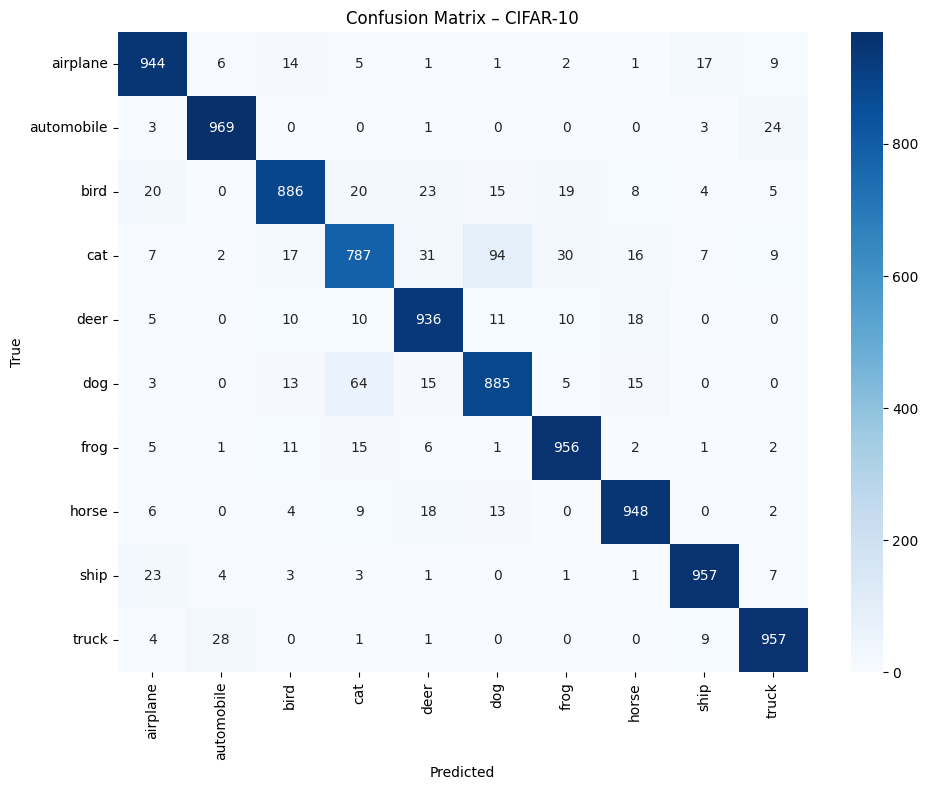

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_cifar10.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        _, pred = model(imgs.to(device)).max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix – CIFAR-10'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

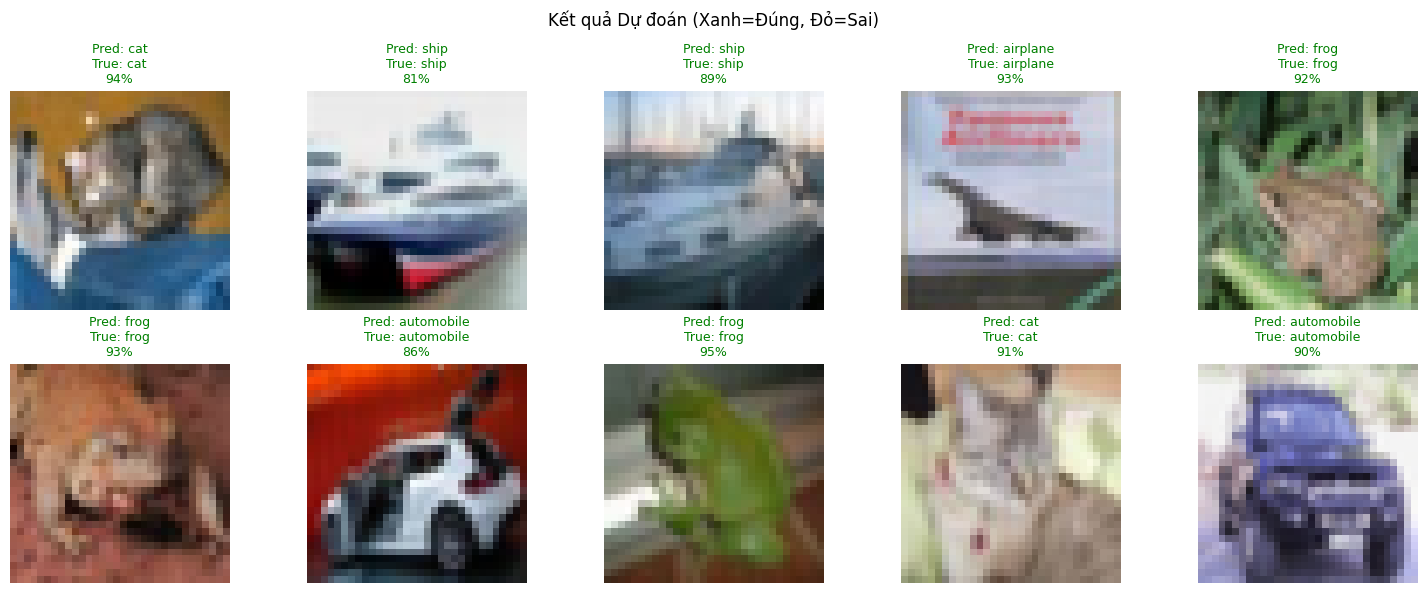

In [8]:
# Dự đoán mẫu
model.eval()
imgs, labels = next(iter(test_loader))
imgs, labels = imgs.to(device), labels.to(device)
with torch.no_grad():
    probs = torch.softmax(model(imgs), dim=1)
    confs, preds = probs.max(1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    img_show = (imgs[i].cpu() * torch.tensor(CIFAR_STD).view(3,1,1)
                + torch.tensor(CIFAR_MEAN).view(3,1,1)).clamp(0,1).permute(1,2,0).numpy()
    ax.imshow(img_show)
    color = 'green' if preds[i].item() == labels[i].item() else 'red'
    ax.set_title(f'Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}\n{confs[i]:.0%}',
                 color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Kết quả Dự đoán (Xanh=Đúng, Đỏ=Sai)', fontsize=12)
plt.tight_layout(); plt.show()